In [ ]:
# This code was developed to forecat  PV power based on the past values of PV power
# P(t)=f(p(t-1),p(t-2),........) using Att-LSTM, LSTM GRU, BiGRU and BiLSTM

import os
import numpy as np
import tensorflow as tf
from tensorflow import keras
import pandas as pd
import seaborn as sns
from pylab import rcParams
import matplotlib.pyplot as plt
from matplotlib import rc
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.layers import Bidirectional, Dropout, Activation, Dense, LSTM, GRU
from tensorflow.keras.models import Sequential
import sklearn.metrics as metrics
%matplotlib inline
sns.set(style='whitegrid', palette='muted', font_scale=1.5)
rcParams['figure.figsize'] = 8, 6
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:

data= pd.read_csv('https://docs.google.com/spreadsheets/d/e/2PACX-1vSoDbyxbYgIP7tjjKQuF3MxtCJTwEYCiaI6uTu2GheWEZbKk7P4jHrBsxZdHby9-_bBv7JfkrqnksVS/pub?gid=139088962&single=true&output=csv')
data

,Sakaka,Hail,Madinah,Riyad,Jeddah,Albaha,Abha,Jazan,Najran,Dammam,Tabuk
0,3.9490,4.3198,4.7542,4.6493,4.9850,5.4269,5.6100,5.3546,5.5627,3.6883,4.3198
1,3.9850,4.4194,4.8377,4.8302,4.9958,5.3618,5.4562,5.2980,5.6040,3.5242,4.4194
2,4.0198,4.1078,4.7765,4.8370,4.8886,5.2519,5.5421,5.1602,5.8394,3.8630,4.1078
3,3.9396,4.4158,4.6195,4.9663,4.7004,5.3026,5.4970,5.3040,5.9419,3.8726,4.4158
4,3.9398,4.2881,4.5127,4.9649,4.7129,5.1134,5.3957,5.3347,5.7223,4.0008,4.2881
...,...,...,...,...,...,...,...,...,...,...,...
5746,6.1757,6.7786,6.0173,6.2280,5.8572,6.1229,6.6310,5.8814,6.9614,5.4643,6.7786
5747,6.1337,6.6113,6.4987,5.9954,6.2441,4.9111,5.4509,5.7158,6.7186,5.6222,6.6113
5748,5.9578,6.2189,6.4829,6.0742,6.2962,6.1723,6.0965,5.5973,7.1671,5.4024,6.2189
5749,5.7437,6.4286,6.2839,6.1298,6.2122,6.5503,6.9600,6.0437,7.0618,5.4636,6.4286


In [ ]:

# Normalisation step
#-------------------

scaler = MinMaxScaler()
Ppv = data.Tabuk.values.reshape(-1, 1)
scaled_IR = scaler.fit_transform(Ppv)

np.isnan(scaled_IR).any()
scaled_IR = scaled_IR[~np.isnan(scaled_IR)]
scaled_IR = scaled_IR.reshape(-1, 1)
np.isnan(scaled_IR).any()
scaled_IR

array([[0.41393963],
       [0.42646116],
       [0.38728738],
       ...,
       [0.652691  ],
       [0.6790541 ],
       [0.69541003]])

/tmp/ipython-input-557877545.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


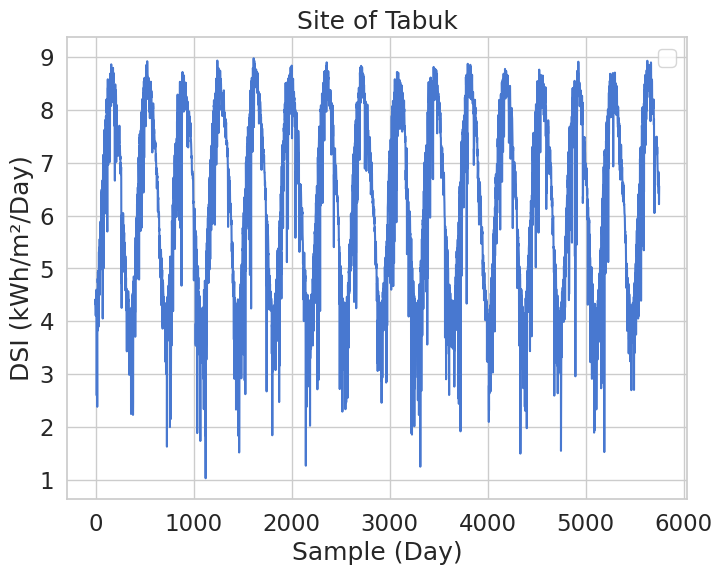

In [ ]:
plt.plot(data.Tabuk)

plt.title('Site of Tabuk')
plt.ylabel('DSI (kWh/m²/Day)')
plt.xlabel('Sample (Day)')
plt.legend()
#plt.savefig('G:/code/results/LSTM-GHItest.png', dpi=300)
plt.show();



In [ ]:
plt.plot(scaled_IR)

plt.title('Site of Tabuk')
plt.ylabel('Normalized DSI ')
plt.xlabel('Sample (Day)')
plt.legend()
#plt.savefig('G:/code/results/LSTM-GHItest.png', dpi=300)
plt.show();


In [ ]:
# data analysis
from statsmodels.graphics.tsaplots import plot_acf

plt.figure()
plot_acf(data.Tabuk, lags=365)  # 2 years for daily data
plt.title("Autocorrelation Function (ACF)")
plt.ylabel('Normalized DSI ')
plt.xlabel('Sample (Day)')
plt.show()

In [ ]:
from pandas.plotting import lag_plot

plt.figure()
lag_plot(data.Tabuk, lag=1)
plt.title("Lag-1 Correlation Plot")
plt.show()


In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomp = seasonal_decompose(data.Tabuk, model="additive", period=365)
decomp.plot()
plt.show()


In [ ]:
rolling_corr = data.Tabuk.rolling(window=365).corr(data.Tabuk.shift(1))

plt.figure()
rolling_corr.plot()
plt.title("Rolling Lag-1 Correlation (365-day window)")
plt.show()


In [ ]:
##Processing
SEQ_LEN =9

def to_sequences(data, seq_len):
    d = []
    for index in range(len(data) - seq_len):
        d.append(data[index: index + seq_len])
    return np.array(d)

def preprocess(data_raw, seq_len, train_split):

    data = to_sequences(data_raw, seq_len)
    num_train = int(train_split * data.shape[0])
    X_train = data[:num_train, :-1, :]
    y_train = data[:num_train, -1, :]
    X_test = data[num_train:, :-1, :]
    y_test = data[num_train:, -1, :]
    return X_train, y_train, X_test, y_test


X_train, y_train, X_test, y_test = preprocess(scaled_IR, SEQ_LEN, train_split = 0.80)

#print(X_train,len(X_train))

In [ ]:
X_train.shape

(4593, 8, 1)

In [ ]:
X_test.shape

(1149, 8, 1)

In [ ]:
#

model = Sequential()
# Bi-LSTM
#model.add(Bidirectional(LSTM(units=100, input_shape=(X_train.shape[1], X_train.shape[2]))))

# Bi-GRU

#model.add(Bidirectional(GRU(units=100, input_shape=(X_train.shape[1], X_train.shape[2]))))

#GRU model
#model.add((GRU(units=100, input_shape=(X_train.shape[1], X_train.shape[2]))))

#LSTM model
model.add((LSTM(units=100, input_shape=(X_train.shape[1], X_train.shape[2]))))

#GRU-LSTM

#model.add(GRU(units=50, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2]))),
#model.add(Dropout(0.2)),
#model.add(LSTM(units=50)),

model.add(Dropout(rate=0.2))
#model.add(Dense(units=10))
model.add(Dense(units=1,activation='relu'))
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_6 (LSTM)                   │ (None, 100)            │        40,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,901 (159.77 KB)

 Trainable params: 40,901 (159.77 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#deeper LSTM
model = Sequential()

# First LSTM layer with return_sequences=True to stack another LSTM
model.add(LSTM(128, activation='relu', return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(Dropout(0.2))  # Add dropout for regularization

# Second LSTM layer
model.add(LSTM(64, activation='tanh', return_sequences=True))
model.add(Dropout(0.2))

# Third LSTM layer
model.add(LSTM(32, activation='tanh'))
model.add(Dropout(0.2))

# Fully connected (Dense) output layer
model.add(Dense(1, activation='relu'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
 #LSTM-GRU
 #LSTM Layer
model = Sequential()
model.add(LSTM(128, activation='relu', return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(Dropout(0.2))  # Add dropout for regularization

# GRU Layer
model.add(GRU(64, activation='relu', return_sequences=False))
model.add(Dropout(0.2))

# Fully connected Dense Layer
model.add(Dense(32, activation='relu'))
model.add(Dense(1))  # Single output for regression

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
# Att-LSTM
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, GRU, LSTM, Dense, Dropout, Layer, Multiply, Permute, Softmax, Lambda
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping
# -----------------------------
# 2. Create sequences
# -----------------------------
def create_sequences(data, SEQ_LEN ):
    X, y = [], []
    for i in range(len(data)-SEQ_LEN):
        X.append(data[i:i+SEQ_LEN])
        y.append(data[i+SEQ_LEN])
    return np.array(X), np.array(y)


X, y = create_sequences(scaled_IR,  SEQ_LEN)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)
# -----------------------------
# 3. Define Attention Layer
# -----------------------------
class Attention(Layer):
    def __init__(self, **kwargs):
        super(Attention, self).__init__(**kwargs)

    def build(self, input_shape):
        self.W = self.add_weight(name="att_weight", shape=(input_shape[-1], input_shape[-1]), initializer="random_normal", trainable=True)
        self.b = self.add_weight(name="att_bias", shape=(input_shape[-1],), initializer="zeros", trainable=True)
        super(Attention, self).build(input_shape)

    def call(self, x):
        # Compute attention scores
        score = tf.nn.tanh(tf.tensordot(x, self.W, axes=1) + self.b)
        attention_weights = tf.nn.softmax(score, axis=1)
        context_vector = attention_weights * x
        context_vector = tf.reduce_sum(context_vector, axis=1)
        return context_vector

# -----------------------------
# 4. Build LSTM, GRU, Bi-LSTM, Bi-GRU + Attention model
# -----------------------------

inputs = Input(shape=(SEQ_LEN, 1))

# Bidirectional LSTM
#lstm_out = Bidirectional(LSTM(100, return_sequences=True))(inputs)

# Bidirectional GRU
#lstm_out = Bidirectional(GRU(100, return_sequences=True))(inputs)

# LSTM
lstm_out = LSTM(100, return_sequences=True)(inputs)

# GRU
#lstm_out = GRU(100, return_sequences=True)(inputs)


attention_out = Attention()(lstm_out)
drop = Dropout(0.2)(attention_out)
outputs = Dense(1)(drop)
model = Model(inputs=inputs, outputs=outputs)
model.compile(optimizer='adam', loss='mean_squared_error')
# -----------------------------
# 5. Train the model
# -----------------------------
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
115/115 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.0957 - val_loss: 0.0077
Epoch 2/100
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0091 - val_loss: 0.0077
Epoch 3/100
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0091 - val_loss: 0.0072
Epoch 4/100
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0085 - val_loss: 0.0075
Epoch 5/100
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0083 - val_loss: 0.0073
Epoch 6/100
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0081 - val_loss: 0.0072
Epoch 7/100
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0087 - val_loss: 0.0072
Epoch 8/100
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0082 - val_loss: 0.0070
Epoch 9/100
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0077 - val_loss: 0.0069
Epoch 10/100
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0082 - val_loss: 0.0069
Epoch 11/100
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0076 - val_loss: 0.0071
Epoch 12/100
115/115 ━━━━━━━━━━━━━━━━━━

In [ ]:
# Training the model

model.compile(loss='mean_squared_error', optimizer='adamax', metrics=['accuracy'])
#history = model.fit( X_train, y_train, epochs=100, batch_size=64, shuffle=False,validation_split=0.1)
history = model.fit( X_train, y_train, epochs=100, batch_size=32,verbose=1)

In [ ]:
# Model evaluation
#model.evaluate(X_test, y_test)

loss_history = history.history["loss"]
loss_ = pd.DataFrame(loss_history)
loss_.columns = ["loss BS=8"]
#loss_.to_csv("G:/code/results/loss-LSTM8.csv")
import numpy
numpy_loss_history = numpy.array(loss_history)
#numpy.savetxt("loss_history.txt", numpy_loss_history, delimiter=",")


In [ ]:
y_pred = model.predict(X_test)
y_train_inverse = scaler.inverse_transform(y_train)
y_test_inverse = scaler.inverse_transform(y_test)
y_pred_inverse = scaler.inverse_transform(y_pred)

mae = metrics.mean_absolute_error(y_test, y_pred)
mse = metrics.mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse) #mse**(0.5)
r2 = metrics.r2_score(y_test, y_pred)
r=np.sqrt(r2)
mape=np.mean(np.abs((y_test - y_pred) / y_test)) * 100

y_pred=np.array(y_pred)
m1=np.mean(y_pred)
y_test=np.array(y_test)
m2=np.mean(y_test)
mrpe=((m2-m1)/m2)*100
print("Results of sklearn.metrics:")
print("MAE:",mae)
print("MAPE:", mape)
print("RMSE:", rmse)
print("R-Squared:", r)
print("MRPE:", mrpe)


36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
Results of sklearn.metrics:
MAE: 0.03888175417746944
MAPE: 9.000781539723617
RMSE: 0.06501157456340775
R-Squared: 0.949274611641041
MRPE: -0.2772709805546552


In [ ]:
%matplotlib inline
sns.set(style='whitegrid', palette='muted', font_scale=1)
rcParams['figure.figsize'] = 8, 6
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

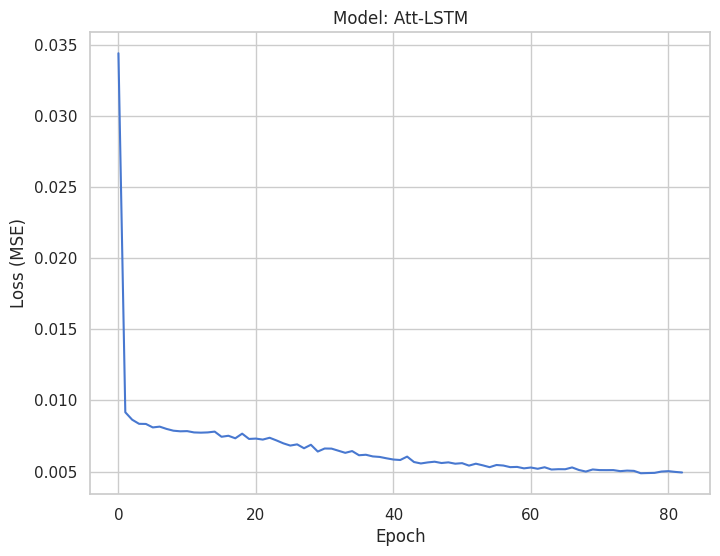

In [ ]:
plt.plot(history.history['loss'])
#plt.plot(history.history['val_loss'])
plt.title('Model: Att-LSTM')
plt.ylabel('Loss (MSE)')
plt.xlabel('Epoch')
#plt.legend(['Train', 'Test'], loc='upper left')
#plt.savefig('E:\new_model.png',dpi=300)
plt.show()

In [ ]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(50)

plt.figure(figsize=(15, 15))
plt.subplot(2, 2, 1)
plt.plot(epochs_range, acc, label='Training accuracy',c='b')
plt.plot(epochs_range, val_acc, label='Validation accuracy',c='r')
#plt.plot(epochs_range, acc, label='Training accuracy',c='r',linestyle="--", linewidth=1)
plt.legend(loc='lower right')
plt.title('Training and validation accuracy (Multi-class classification)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.subplot(2, 2, 2)
plt.plot(epochs_range, loss, label='Training loss',c='b')
plt.plot(epochs_range, val_loss, label='Validation loss',c='r')
plt.legend(loc='upper right')
plt.title('Training and validation loss(Multi-class classification)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

# Prediction

In [ ]:
# Store the results
res_ = pd.DataFrame(y_pred_inverse)
res_.columns = ["Prediction"]

res = pd.DataFrame(y_test_inverse)
res.columns = ["Actual"]

path = '/content/drive/My Drive/Forecast.csv'
with open(path, 'w', encoding = 'utf-8-sig') as f:
  res_.to_csv(f)
path = '/content/drive/My Drive/Actual.csv'
with open(path, 'w', encoding = 'utf-8-sig') as f:
  res.to_csv(f)

## MSE
mse_lstm = pd.DataFrame(history.history['loss'])
mse_lstm.columns = ["lossLSTM"]
path = '/content/drive/My Drive/mseLSTM.csv'
with open(path, 'w', encoding = 'utf-8-sig') as f:
  mse_lstm.to_csv(f)


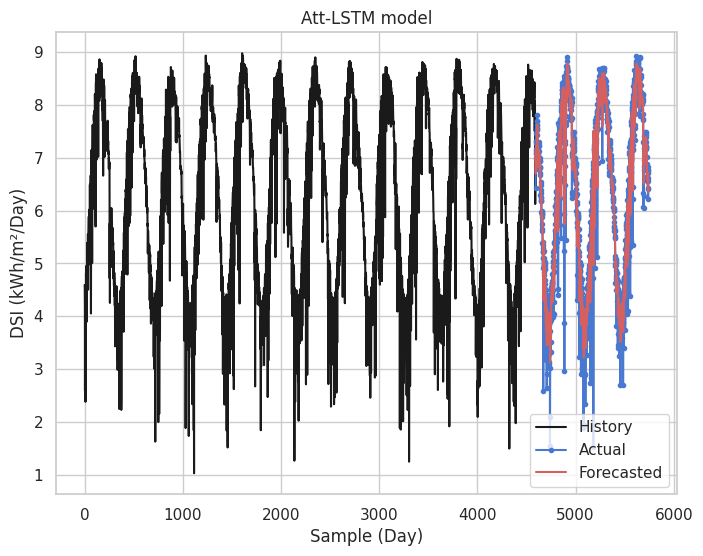

In [ ]:
plt.plot(np.arange(0, len(y_train)), y_train_inverse.flatten(), 'k', label="History")
plt.plot(np.arange(len(y_train), len(y_train) + len(y_test)), y_test_inverse.flatten(), marker='.', label="Actual")
plt.plot(np.arange(len(y_train), len(y_train) + len(y_test)), y_pred_inverse.flatten(), 'r', label="Forecasted")
plt.title('Att-LSTM model')
plt.ylabel('DSI (kWh/m²/Day)')
plt.xlabel('Sample (Day)')
plt.legend()
#plt.savefig('G:/code/results/LSTM-GHI.png',dpi=300)
plt.show();


In [ ]:
plt.plot(y_test_inverse.flatten(), marker='.', label="Measured")
plt.plot(y_pred_inverse.flatten(), 'r', label="Forecasted")
plt.title('Att-LSTM model')
plt.ylabel('DSI (kWh/m²/Day)')
plt.xlabel('Sample (Day)')
plt.legend()
#plt.savefig('G:/code/results/LSTM-GHItest.png', dpi=300)
plt.show();

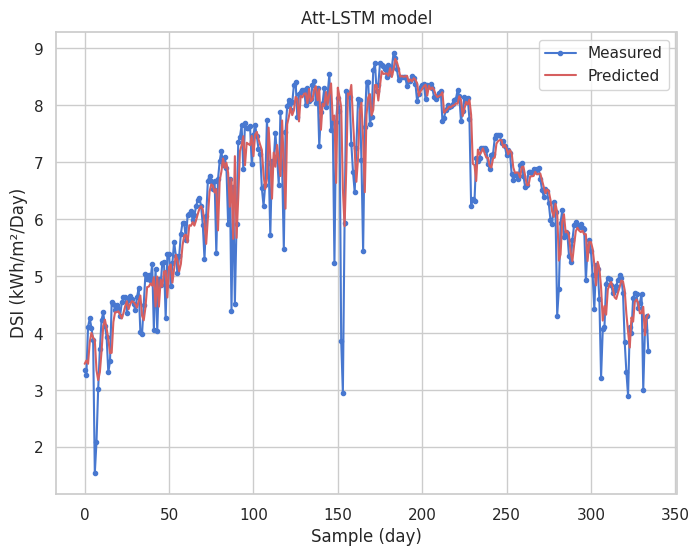

In [ ]:
plt.plot(y_test_inverse[140:475], marker='.', label="Measured")
plt.plot(y_pred_inverse[140:475], 'r', label="Predicted")
plt.title('Att-LSTM model')
plt.ylabel('DSI (kWh/m²/Day)')
plt.xlabel('Sample (day)')
plt.legend()
#plt.savefig('G:/code/results/LSTM-GHItest.png', dpi=300)
plt.show();

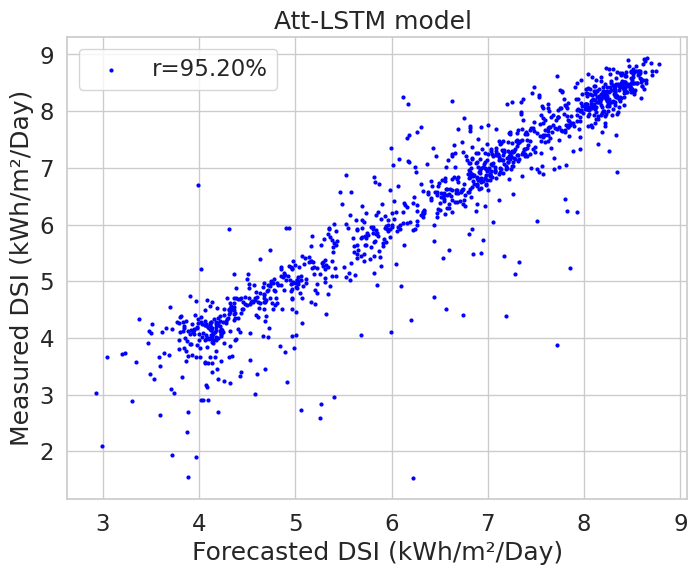

In [ ]:

plt.scatter(y_pred_inverse,y_test_inverse, s=4, color='blue',label="r=95.20%")
plt.title('Att-LSTM model ')
plt.ylabel("Measured DSI (kWh/m²/Day)")
plt.xlabel("Forecasted DSI (kWh/m²/Day)")
plt.legend()
#plt.title("Scatter plot")
#plt.savefig('G:/code/results/LSTMscater.png',dpi=300)
plt.show();




In [ ]:
from numpy import loadtxt
# save model and architecture to single file
model.save("my_model_ubuntu_99_percent.h5")
print("Saved model to disk")

In [ ]:
import os
import numpy as np
import tensorflow as tf
from tensorflow import keras
import pandas as pd
import seaborn as sns
from pylab import rcParams
import matplotlib.pyplot as plt
from matplotlib import rc
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.layers import Bidirectional, Dropout, Activation, Dense, LSTM, GRU
from tensorflow.keras.models import Sequential
import sklearn.metrics as metrics
%matplotlib inline
sns.set(style='whitegrid', palette='muted', font_scale=1.5)
rcParams['figure.figsize'] = 8, 6
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
test1 = pd.read_csv('/content/drive/MyDrive/outputLSTM.csv')
test1

Mounted at /content/drive


,Unnamed: 0,Prediction
0,0,7.149108
1,1,6.665876
2,2,7.111113
3,3,7.023969
4,4,6.968480
...,...,...
1144,1144,6.441289
1145,1145,6.704184
1146,1146,6.554963
1147,1147,6.308389


In [ ]:
#v=test1.Prediction[500:500+365]
v = test1.Prediction.iloc[500:500+365]
v.index = range(1, len(v)+1)
#Ppv=4;
Ppv=8;
eff=0.8;
Epv=Ppv*eff*v


/tmp/ipython-input-830050934.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


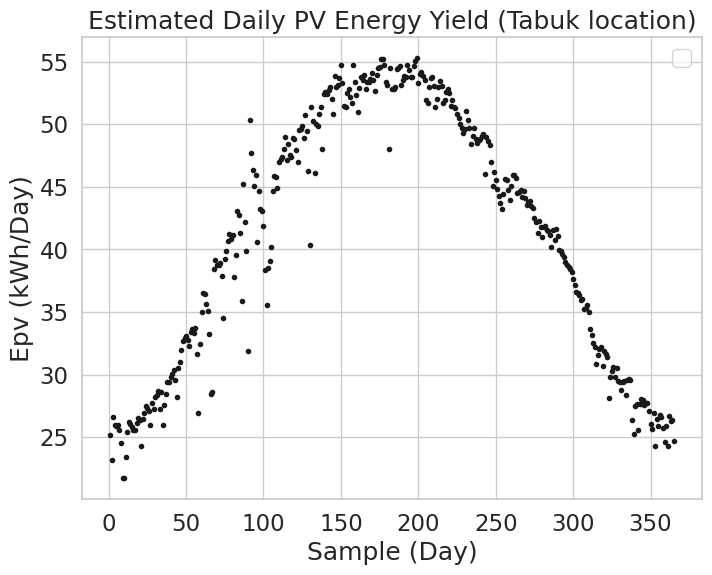

In [ ]:
plt.plot(Epv, 'k.' )
plt.title('Estimated Daily PV Energy Yield (Tabuk location)')
plt.ylabel('Epv (kWh/Day)')
plt.xlabel('Sample (Day)')
plt.legend()
plt.show();

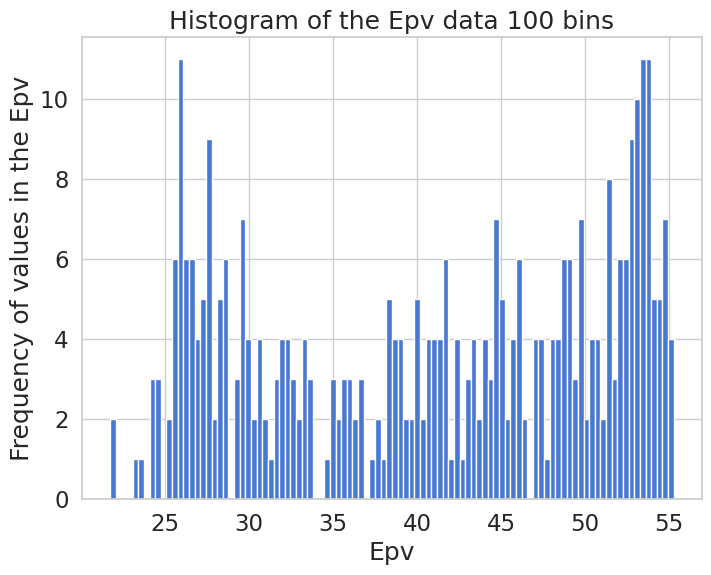

In [ ]:
ax2 = Epv.plot(kind='hist', bins=100)
ax2.set_xlabel('Epv')
ax2.set_ylabel('Frequency of values in the Epv')
ax2.set_title('Histogram of the Epv data 100 bins')
plt.show()

In [ ]:
monthly_sum = Epv.resample('M').sum()

plt.figure(figsize=(7,4))
plt.bar(monthly_sum.index.strftime('%b'), monthly_sum.values)

plt.ylabel('Monthly Energy (kWh)')
plt.xlabel('Month')
plt.title('Monthly PV Energy Production')
plt.grid(axis='y', alpha=0.3)

plt.show()

In [ ]:
print(v.head())

1    3.938650
2    3.625012
3    4.157896
4    4.056493
5    4.047391
Name: Prediction, dtype: float64


Text(0.5, 0, 'Count')

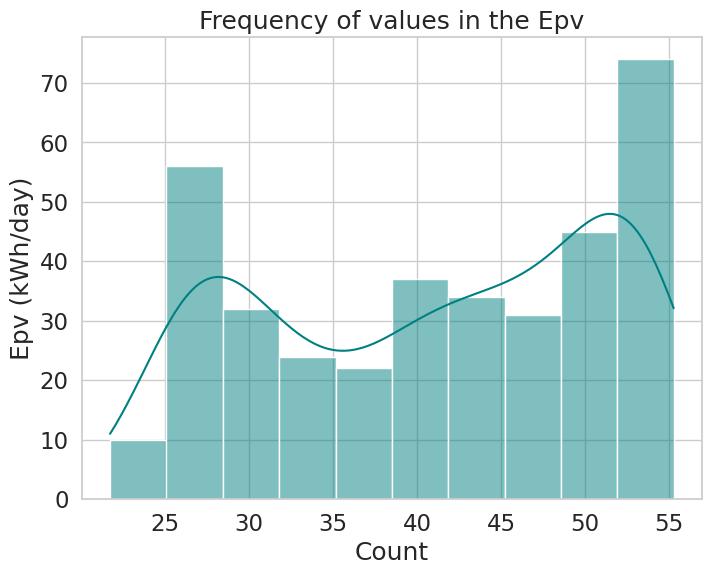

In [ ]:



import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Distribution of Energy
sns.histplot(Epv, kde=True, color='teal')
plt.title('Frequency of values in the Epv')
plt.ylabel('Epv (kWh/day)')
plt.xlabel('Count')



In [ ]:
# 2. Heatmap of Demand
heatmap_data = df.groupby(['day_of_week', 'hour'])['energy_kwh'].sum().unstack()
sns.heatmap(heatmap_data, cmap='YlGnBu')
plt.title('Energy Demand: Day vs Hour')

# 3. Boxplot for Variability
sns.boxplot(x='hour', y='energy_kwh', data=df)
plt.title('Energy Consumption Variability by Arrival Hour')

NameError: name 'df' is not defined

In [ ]:
import pandas as pd

v = test1.Prediction[500:500+365]   # your Series
Epv=Ppv*0.8*v
# create daily dates (change start date if needed)
dates = pd.date_range(start='2024-01-01', periods=len(Epv), freq='D')

# assign dates as index
Epv.index = dates

print(Epv.head())

2024-01-01    25.207360
2024-01-02    23.200079
2024-01-03    26.610532
2024-01-04    25.961555
2024-01-05    25.903302
Freq: D, Name: Prediction, dtype: float64


Text(0.5, 1.0, 'Energy Distribution ')

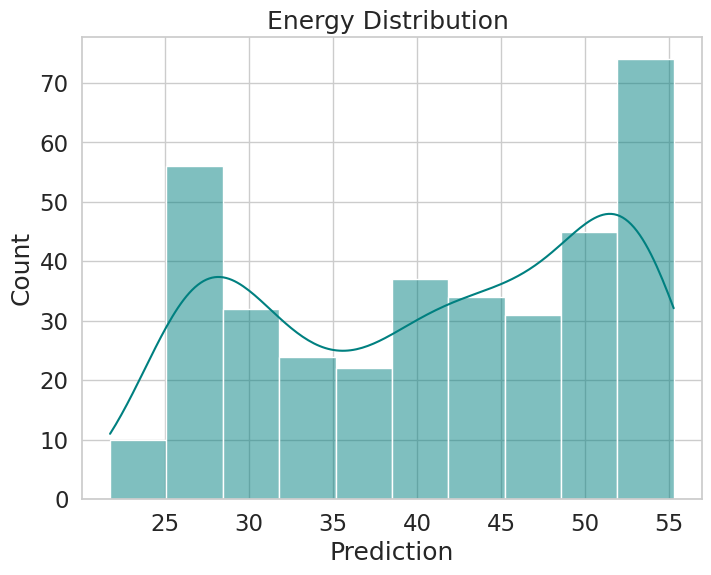

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Distribution of Energy
sns.histplot(Epv, kde=True, color='teal')
plt.title('Energy Distribution ')

In [ ]:
Epv

,Prediction
2024-01-01,25.207360
2024-01-02,23.200079
2024-01-03,26.610532
2024-01-04,25.961555
2024-01-05,25.903302
...,...
2024-12-26,24.338306
2024-12-27,26.706915
2024-12-28,26.278950
2024-12-29,26.383584


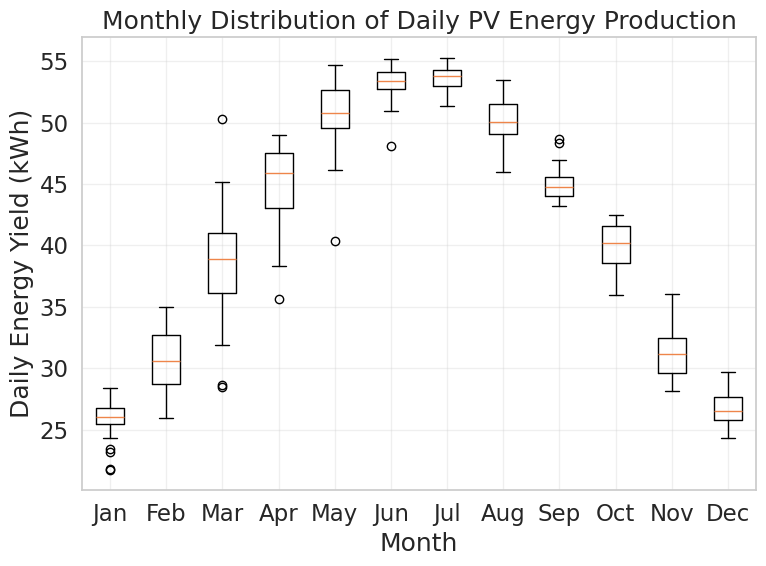

In [ ]:
import matplotlib.pyplot as plt

# group daily values by month
monthly_data = [Epv[Epv.index.month == m] for m in range(1, 13)]

#plt.figure(figsize=(8,4))
plt.boxplot(monthly_data, showfliers=True)

plt.xticks(range(1,13),
           ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])

plt.ylabel('Daily Energy Yield (kWh)')
plt.xlabel('Month')
plt.title('Monthly Distribution of Daily PV Energy Production')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

# ensure daily frequency
Epv = Epv.asfreq('D')

result = seasonal_decompose(Epv, model='additive', period=365)

fig = result.plot()
fig.set_size_inches(8,6)

plt.tight_layout()
plt.show()

In [ ]:

monthly = Epv.resample('M').sum()

monthly.plot(marker='o')
plt.xlabel('Month')
plt.ylabel('Energy (kWh)')
plt.title('Monthly Energy Production')
plt.grid(True)
plt.show()

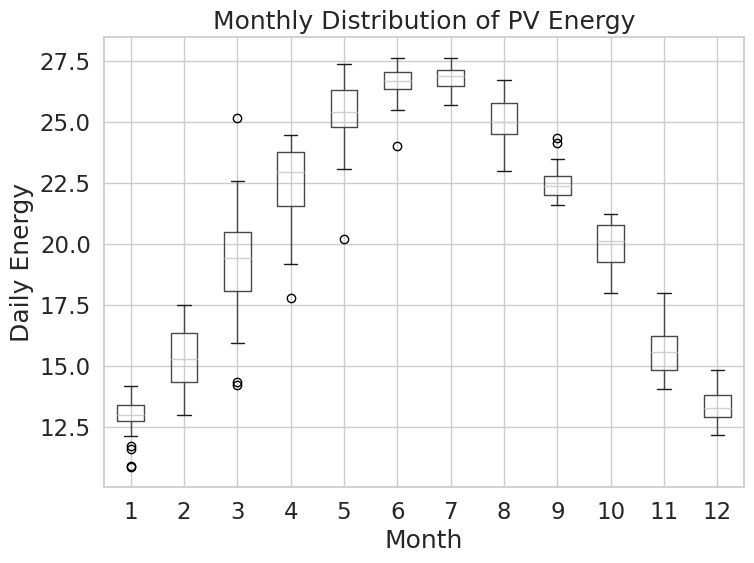

In [ ]:
import pandas as pd

df = Epv.to_frame(name='Epv')
df['month'] = df.index.month

df.boxplot(column='Epv', by='month')
plt.xlabel('Month')
plt.ylabel('Daily Energy')
plt.title('Monthly Distribution of PV Energy')
plt.suptitle('')
plt.show()

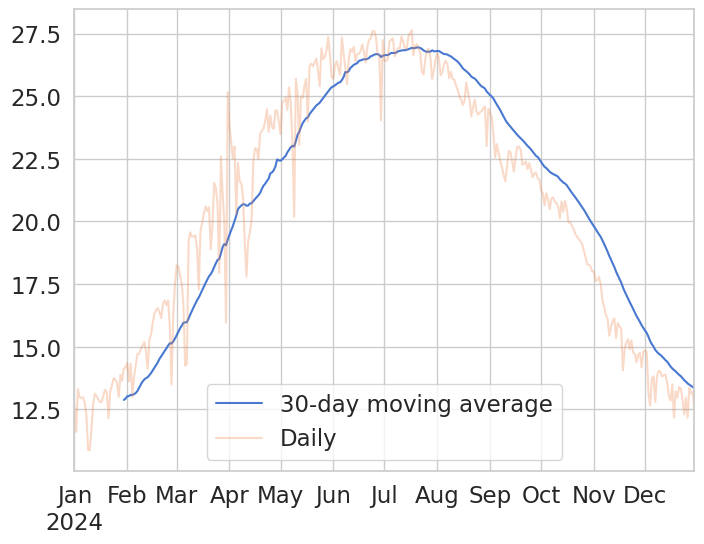

In [ ]:
Epv.rolling(30).mean().plot(label='30-day moving average')
Epv.plot(alpha=0.3, label='Daily')
plt.legend()
plt.show()

In [ ]:
monthly = Epv.resample('M').sum()


result = seasonal_decompose(monthly, model='additive', period=6)
result.plot()
plt.show()

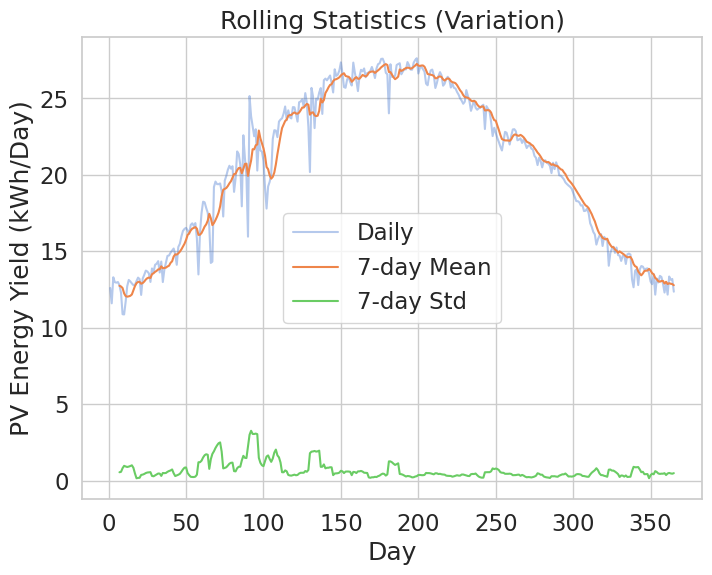

In [ ]:
# Rolling mean + std (variation over time)  good for forecasting
window = 7

rolling_mean = Epv.rolling(window).mean()
rolling_std = Epv.rolling(window).std()

#plt.figure(figsize=(10,4))
plt.plot(Epv, alpha=0.4, label="Daily")
plt.plot( rolling_mean, label="7-day Mean")
plt.plot( rolling_std, label="7-day Std")

plt.legend()
plt.xlabel("Day")
plt.ylabel("PV Energy Yield (kWh/Day)")
plt.title("Rolling Statistics (Variation)")
plt.show()

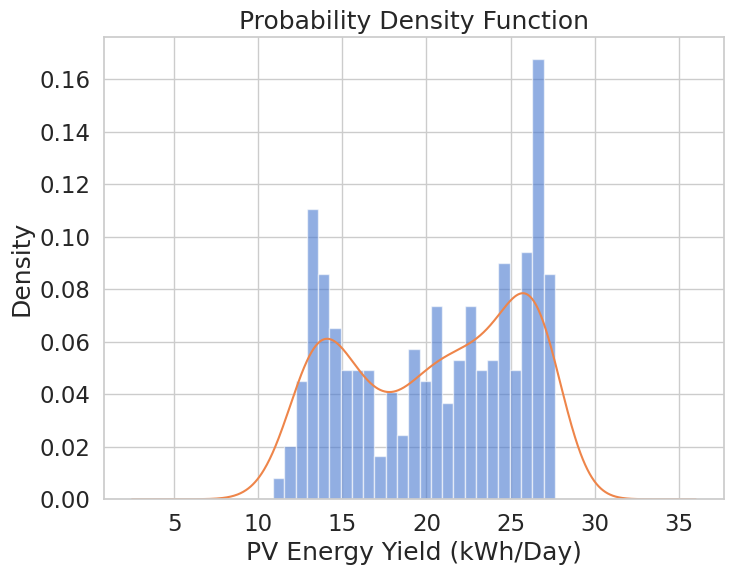

In [ ]:
Epv.plot(kind="hist", bins=25, density=True, alpha=0.6)

Epv.plot(kind="kde")

plt.xlabel("PV Energy Yield (kWh/Day)")
plt.title("Probability Density Function")
plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
forcast = pd.read_csv('/content/drive/MyDrive/Forecast.csv')
Gf=Gf.Prediction

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
%matplotlib inline
sns.set(style='whitegrid', palette='muted', font_scale=1.5)
rcParams['figure.figsize'] = 8, 6
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

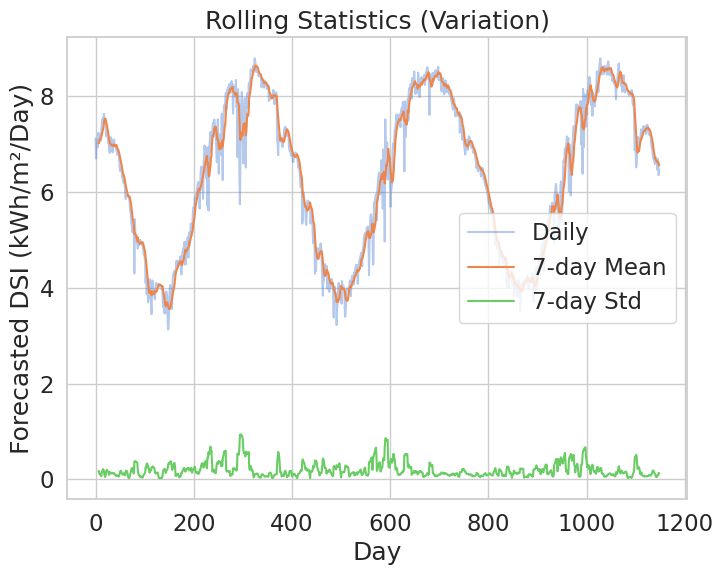

In [ ]:
# Rolling mean + std (variation over time)  good for forecasting
window = 7
Gf
rolling_mean = Gf.rolling(window).mean()
rolling_std = Gf.rolling(window).std()

#plt.figure(figsize=(10,4))
plt.plot(Gf, alpha=0.4, label="Daily")
plt.plot( rolling_mean, label="7-day Mean")
plt.plot( rolling_std, label="7-day Std")

plt.legend()
plt.xlabel("Day")
plt.ylabel("Forecasted DSI (kWh/m²/Day)")
plt.title("Rolling Statistics (Variation)")
plt.show()

In [ ]:
import math
y=math.sqrt(0.95)
y

0.9746794344808963